In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def options(input):

    doors=[0,0,1] #the arawrd is in the 3rd door in this care

    index = np.random.randint(0, len(doors))

    chosen = doors[index]
    notchosen = np.delete(doors,index)
                          
    #open one goat amongs those dont choosed
    index2 = np.where(notchosen == 0)[0][0]

    #choose the option
    if input=='keep':
        return chosen
        
    if input=='switch':
        keep=np.delete(notchosen,index2)
        return keep

    if input=='External':
        index3=doors.index(0)
        doorsnew=np.delete(doors,index3)
        index4 = np.random.randint(0, len(doorsnew))
        chosen = doorsnew[index4]
        return chosen



Text(0.5, 0, 'Desision')

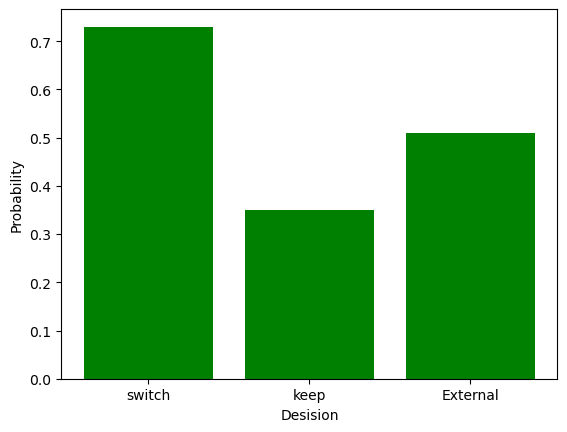

In [3]:
N  = 100 # how many events
outcome = {}

for input in ['switch','keep','External']:
    events = [options(input) for i in range(N)]
    outcome[input] = np.sum(events)/ N

plt.bar([0,1,2], [outcome[k] for k in outcome.keys()], color='green');
plt.ylabel('Probability')
plt.xticks([0,1,2], outcome.keys());
plt.xlabel('Desision')


In [4]:
# for N doors and the presenter open p less than N :)

In [5]:
#i will assume again we are with the 3 scenarios

def options(input, N, p):

    doors = [0] * N
    doors[np.random.randint(0, N-1)] = 1
    
    index = np.random.randint(0, len(doors))

    chosen = doors[index]
    notchosen = np.delete(doors,index)
                          
    #open one goat amongs those dont choosed
    index2 = np.where(notchosen == 0)[0][:p]
    
    #choose the option
    if input=='keep':
        return chosen
        
    if input=='switch':
        keep=np.delete(notchosen,index2)
        index = np.random.randint(0, len(keep))
        chosen=keep[index]
        return chosen

    if input=='External':
        index3 = np.where(np.array(doors) == 0)[0][:p]
        doorsnew=np.delete(doors,index3)
        index4 = np.random.randint(0, len(doorsnew))
        chosen = doorsnew[index4]
        return chosen



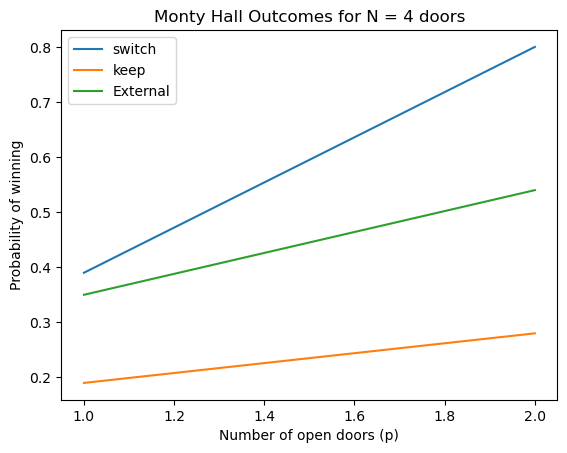

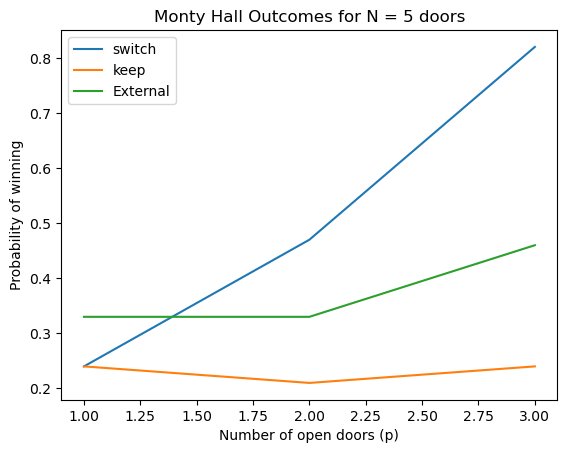

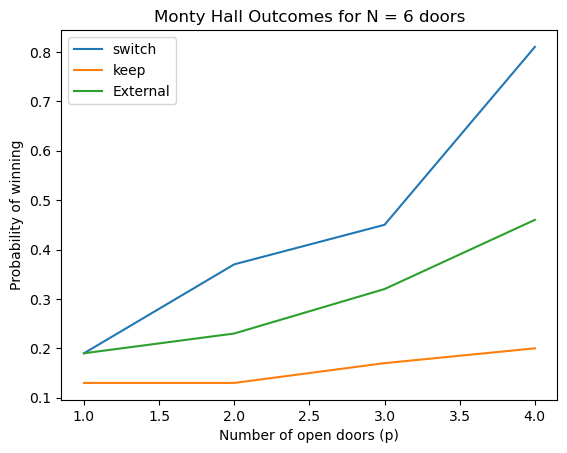

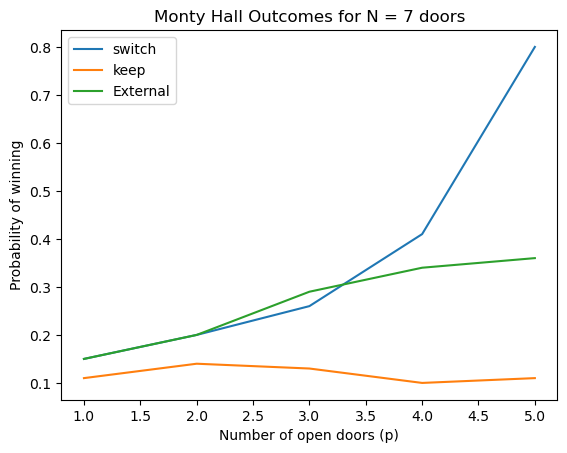

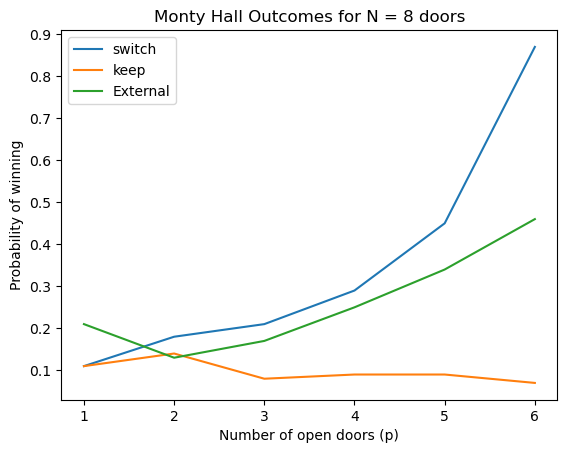

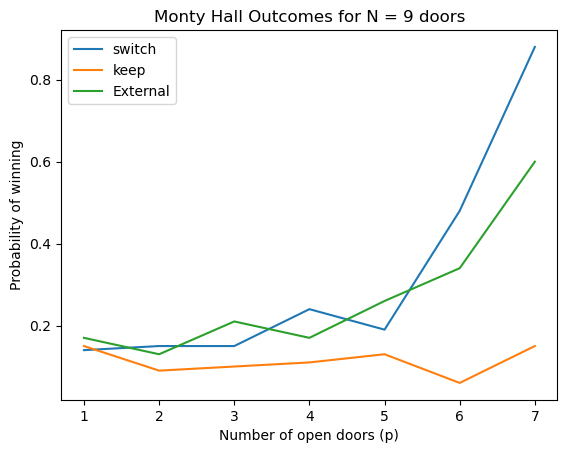

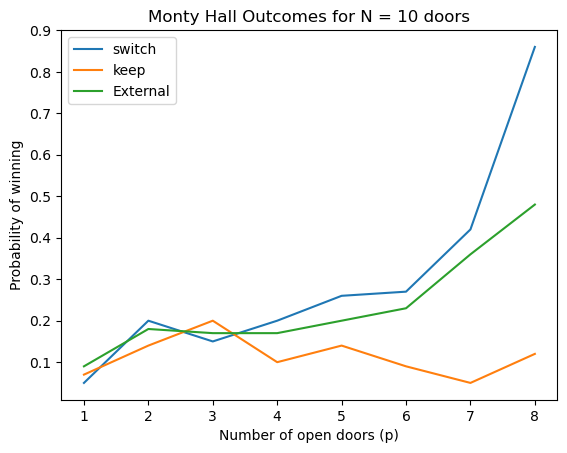

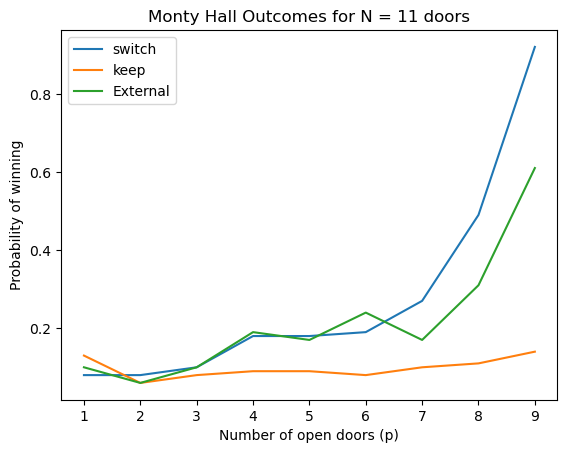

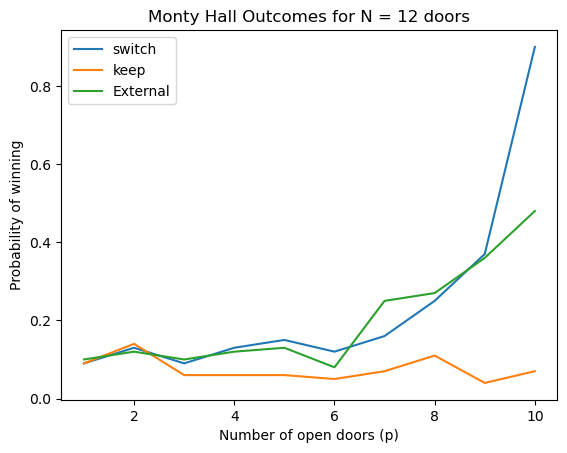

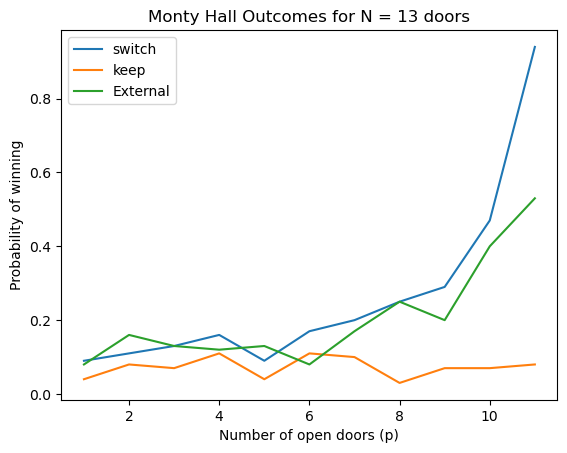

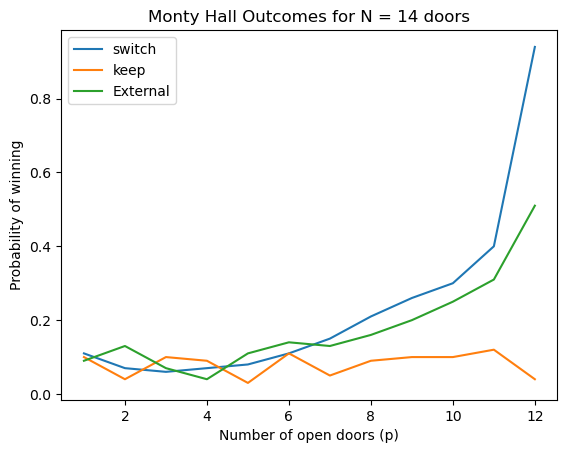

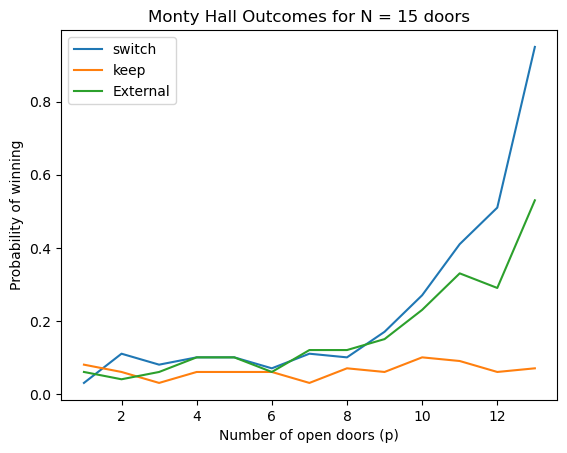

In [6]:
N_e = 100  # number of events

N_range = range(4, 16)  # doors

# desisions
strategies = ['switch', 'keep', 'External']

for N in N_range:
    p = list(range(1, N-1))  # p less or equal to 
    outcome = {strategy: [] for strategy in strategies}

    for i in p:
        for strategy in strategies:
            events = [options(strategy, N, i) for _ in range(N_e)]
            prob = np.sum(events) / N_e
            outcome[strategy].append(prob)

    plt.figure()
    for strategy in strategies:
        plt.plot(p, outcome[strategy], label=strategy)

    plt.xlabel('Number of open doors (p)')
    plt.ylabel('Probability of winning')
    plt.legend()
    plt.title(f'Monty Hall Outcomes for N = {N} doors')
    plt.show()